In [ ]:
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from stac_utils import convert_timerange
from pathlib import Path

tstr = "%Y-%m-%d"

catalog = "/home/Aria.Radick/Documents/catalogs/cmip_spear-med_hist/catalog.csv"

output_path_template = ['institution_id','source_id','experiment_id','member_id',"table_id","variable_id","grid_label","version_id"]
output_file_template = ["variable_id","table_id",'source_id',"experiment_id",'member_id',"grid_label"]
base_path = '/work/a3r/Documents/code/stac-scripts/catalog_thumbs/'

/nbhome/a3r/conda/envs/python_venv/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
dfcat = pd.read_csv(catalog)
dfcat = dfcat.dropna(axis=1, how='all')

In [ ]:
n = 10
dfcat[dfcat['member_id'] == f'r{n}i1p1f1']

In [ ]:
def get_thumb_path(row, output_path=output_path_template, 
                       output_file=output_file_template,
                       base_path=base_path,
                       create=False):
    path = base_path + '/'.join(row[output_path_template]) + '/' 
    if create:
        Path(path).mkdir(parents=True, exist_ok=True)
    fname = '_'.join(row[output_file_template]) + '.png'

    return path+fname

def thumb_exists(row):
    os.path.isfile(get_thumb_path(row))

def get_subcat(catalog, cat_entry):
    row_filter = cat_entry[(catalog.columns != 'path') & 
                           (catalog.columns != 'time_range')]
    truths = (catalog.loc[:,((catalog.columns != 'path') & 
             (catalog.columns != 'time_range'))] == row_filter).all(axis=1)
    return catalog[truths]

def get_time_avg(subcatalog):
    var_id = subcatalog.iloc[0]['variable_id']
    paths = subcatalog['path']
    ds0 = xr.open_dataset(paths.iloc[0])[var_id].mean(dim='time', keep_attrs=True)
    for p in paths.iloc[1:]:
        ds0 += xr.open_dataset(p)[var_id].mean(dim='time')
    ds0 /= len(paths)
    return ds0

def get_time_str(subcatalog):
    times = subcatalog["time_range"].apply(convert_timerange).to_list()
    times_flat = [x for xs in times for x in xs]
    t0 = min(times_flat)
    t1 = max(times_flat)
    return f"{t0.strftime(tstr)} – {t1.strftime(tstr)}"

def generate_plot(ds_avg, time_str, ens_id, exp_id):
    fig = plt.figure(figsize = (10, 5))
    axis = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    axis.coastlines()
    p = ds_avg.plot(ax = axis, add_colorbar=False, center=273.15)
    plt.colorbar(mappable=p, label=f"{ds_avg.name} [{ds_avg.attrs['units']}]")
    plt.title(f"Average {ds_avg.attrs['long_name']} {time_str}")
    plt.text(0, -0.1, 'GFDL-SPEAR-MED', ha='left', va='bottom', transform=axis.transAxes)
    plt.text(0.5, -0.1, exp_id, ha='center', va='bottom', transform=axis.transAxes)
    plt.text(1, -0.1, ens_id, ha='right', va='bottom', transform=axis.transAxes)
    return fig

def _make_thumb(row, catalog):
    thumb_path = get_thumb_path(row, create=True)
    # if os.path.isfile(thumb_path):
    #     return
    # else:
    subcat = get_subcat(catalog, row)
    ds_avg = get_time_avg(subcat)
    generate_plot(ds_avg, get_time_str(subcat), row['member_id'], row['experiment_id'])#.savefig(thumb_path, bbox_inches="tight")

def main(catalog):
    catalog.apply(_make_thumb, axis=1, args=(catalog,))

In [6]:
subcat = get_subcat(dfcat, dfcat.iloc[95])
ds_avg = get_time_avg(subcat)

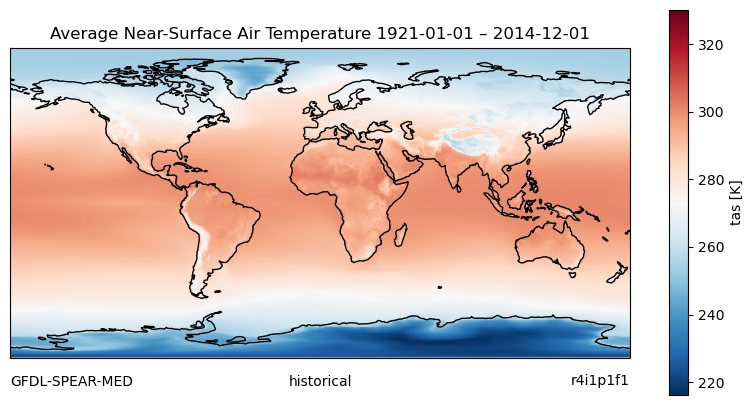

In [9]:
x = generate_plot(ds_avg, get_time_str(subcat), dfcat.iloc[95]['member_id'], dfcat.iloc[95]['experiment_id'])

In [ ]:
testavg

In [ ]:
xr.open_dataset(dfcat.iloc[95]['path'])['tas'].attrs

In [ ]:
get_thumb_path(dfcat.iloc[95], create=True)

In [ ]:
fig = plt.figure(figsize = (10, 5))
axis = fig.add_subplot(1, 1, 1)
testavg.plot(ax = axis)
plt.title(f"Temporal average {t0.strftime(tstr)} – {t1.strftime(tstr)}")
fig.savefig(get_thumb_path(dfcat.iloc[95], create=True))